# PyTorch Autograd: Diferenciação Automática e Gradiente Descendente

## Objetivos desta Aula

Este notebooks cobre os fundamentos de **diferenciação automática** em PyTorch:

1. ✅ Como o PyTorch calcula derivadas automaticamente (Autograd)
2. ✅ Construção e navegação do **grafo computacional** (DAG)
3. ✅ Aplicação prática: **Gradiente Descendente** em 1D e 2D
4. ✅ Armadilhas comuns e como evitá-las

Você aprenderá implementando exemplos reais e visualizando os resultados.

## Setup e Imports

Primeiro, vamos importar as bibliotecas necessárias:

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Parte 1: Derivadas Automáticas em 1D

## Autograd: O que é?

Quando você marca um tensor com `requires_grad=True`, o PyTorch registra automaticamente cada operação em um **grafo computacional**. Ao chamar `.backward()`, ele percorre esse grafo de trás para frente calculando derivadas usando a **regra da cadeia**.

### Exemplo: Derivada de $f(x) = x^3 - 2x^2 + x + 1$

Vamos comparar o autograd com a derivada analítica: $f'(x) = 3x^2 - 4x + 1$

In [3]:
# Criar pontos para avaliação da função
x_vals = np.linspace(-3, 3, 400)
f_vals = []
grad_vals = []

# Para cada ponto, calcular f(x) e f'(x) usando autograd
for xi in x_vals:
    # PASSO 1: Criar um tensor que enable rastreamento
    x = torch.tensor([xi], dtype=torch.float64, requires_grad=True)

    # PASSO 2: Definir a função (construir o grafo computacional)
    y = x**3 - 2*x**2 + x + 1

    # PASSO 3: Chamar backward() para calcular derivadas
    y.backward()

    # PASSO 4: Acessar o gradiente acumulado em x.grad
    f_vals.append(y.item())
    grad_vals.append(x.grad.item())

f_vals = np.array(f_vals)
grad_vals = np.array(grad_vals)

# Derivada analítica para comparação
analytic_grad = 3*x_vals**2 - 4*x_vals + 1

# Calcular erro absoluto máximo
max_error = np.max(np.abs(grad_vals - analytic_grad))
print(f"Erro máximo (Autograd vs Analítica): {max_error:.2e}")
print(f"✓ Precisão validada! (esperado ~1e-9)")

Erro máximo (Autograd vs Analítica): 3.55e-15
✓ Precisão validada! (esperado ~1e-9)


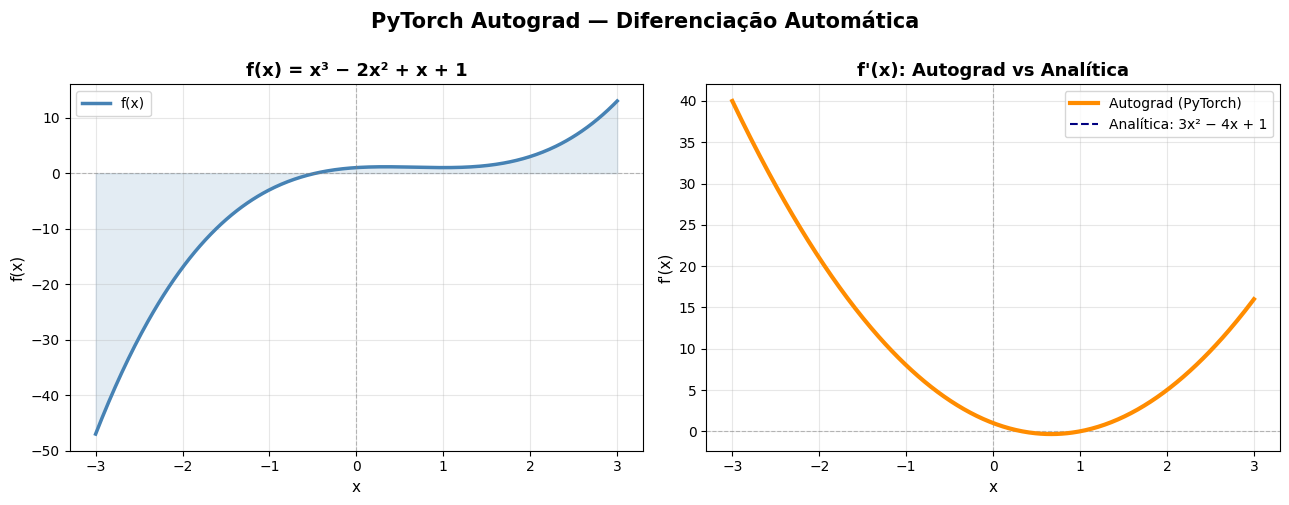

In [6]:
# Visualizar função e derivadas
fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='white')

# Painel 1: A função f(x)
axes[0].plot(x_vals, f_vals, color='steelblue', lw=2.5, label='f(x)')
axes[0].axhline(0, color='gray', lw=0.8, ls='--', alpha=0.5)
axes[0].axvline(0, color='gray', lw=0.8, ls='--', alpha=0.5)
axes[0].fill_between(x_vals, f_vals, alpha=0.15, color='steelblue')
axes[0].set_title('f(x) = x³ − 2x² + x + 1', fontsize=13, fontweight='bold')
axes[0].set_xlabel('x', fontsize=11)
axes[0].set_ylabel('f(x)', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Painel 2: Comparação das derivadas
axes[1].plot(x_vals, grad_vals, color='darkorange', lw=3.0,
             label='Autograd (PyTorch)', zorder=3)
axes[1].plot(x_vals, analytic_grad, color='navy', lw=1.5, ls='--',
             label="Analítica: 3x² − 4x + 1", zorder=2)
axes[1].axhline(0, color='gray', lw=0.8, ls='--', alpha=0.5)
axes[1].axvline(0, color='gray', lw=0.8, ls='--', alpha=0.5)
axes[1].set_title("f'(x): Autograd vs Analítica", fontsize=13, fontweight='bold')
axes[1].set_xlabel('x', fontsize=11)
axes[1].set_ylabel("f'(x)", fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle('PyTorch Autograd — Diferenciação Automática', fontsize=15,
             fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('autograd_derivada.png', dpi=100, facecolor='white', edgecolor='none', bbox_inches='tight')
plt.show()

# Parte 2: Jacobiana em Funções Multidimensionais

A **Jacobiana** é a matriz de derivadas parciais para funções vetoriais.

Para $\mathbf{y} = f(\mathbf{x})$ onde $\mathbf{x} \in \mathbb{R}^n$ e $\mathbf{y} \in \mathbb{R}^m$:

$$J = \begin{bmatrix} \frac{\partial y_1}{\partial x_1} & \cdots & \frac{\partial y_1}{\partial x_n} \\ \vdots & \ddots & \vdots \\ \frac{\partial y_m}{\partial x_1} & \cdots & \frac{\partial y_m}{\partial x_n} \end{bmatrix}$$

# Parte 2: Gradiente Descendente 2D

## Otimização com Autograd

A ideia do gradiente descendente é simples:
1. **Calcular** o gradiente (inclinação) da função
2. **Seguir** na direção contrária (descida)
3. **Repetir** até convergência

$$\theta_{novo} = \theta_{atual} - \alpha \cdot \nabla_\theta \mathcal{L}(\theta)$$

### Exemplo: Minimizar $f(x, y) = x^2 + 2y^2$

**Mínimo global**: $(0, 0)$ com $f(0, 0) = 0$

Note que $2y^2$ tem maior curvatura, então converge mais rápido em $y$.

In [7]:
# Inicializar variáveis com requires_grad=True
# para que o PyTorch rastreie suas derivadas
x = torch.tensor([2.5], dtype=torch.float64, requires_grad=True)
y = torch.tensor([2.0], dtype=torch.float64, requires_grad=True)

# Hyperparâmetros de otimização
learning_rate = 0.15  # quanto anda a cada passo
n_iterations = 40     # quantas iterações fazer

# Armazenar histórico para visualização posterior
history = {'x': [], 'y': [], 'loss': []}

print(f"{'Iter':<6} {'x':>10} {'y':>10} {'Loss':>12}")
print("-" * 42)

for iteration in range(n_iterations):
    # Guardar estado atual antes de calcular
    history['x'].append(x.item())
    history['y'].append(y.item())

    # ──────────────────────────────────────────────
    # FORWARD PASS: Calcular a loss
    # ──────────────────────────────────────────────
    loss = x**2 + 2*y**2
    history['loss'].append(loss.item())

    # IMPORTANTE: Zerar gradientes acumulados ⚠️
    # PyTorch acumula por padrão, então é obrigatório limpar
    if x.grad is not None:
        x.grad.zero_()
    if y.grad is not None:
        y.grad.zero_()

    # ──────────────────────────────────────────────
    # BACKWARD PASS: Calcular derivadas
    # ──────────────────────────────────────────────
    loss.backward()

    # Mostrar progresso a cada 10 iterações
    if iteration % 10 == 0:
        print(f"{iteration:<6} {x.item():>10.6f} {y.item():>10.6f} {loss.item():>12.6f}")

    # ──────────────────────────────────────────────
    # ATUALIZAÇÃO: Aplicar gradiente descendente
    # ──────────────────────────────────────────────
    with torch.no_grad():  # Não registrar essa operação no grafo!
        x -= learning_rate * x.grad
        y -= learning_rate * y.grad

print("-" * 42)
print(f"\n✓ Otimização concluída!")
print(f"  Ponto final: x = {x.item():.8f}, y = {y.item():.8f}")
print(f"  Loss inicial: {history['loss'][0]:.6f}")
print(f"  Loss final:   {history['loss'][-1]:.8f}")
print(f"  Redução: {(1 - history['loss'][-1]/history['loss'][0])*100:.2f}%")

Iter            x          y         Loss
------------------------------------------
0        2.500000   2.000000    14.250000
10       0.070619   0.000210     0.004987
20       0.001995   0.000000     0.000004
30       0.000056   0.000000     0.000000
------------------------------------------

✓ Otimização concluída!
  Ponto final: x = 0.00000159, y = 0.00000000
  Loss inicial: 14.250000
  Loss final:   0.00000000
  Redução: 100.00%


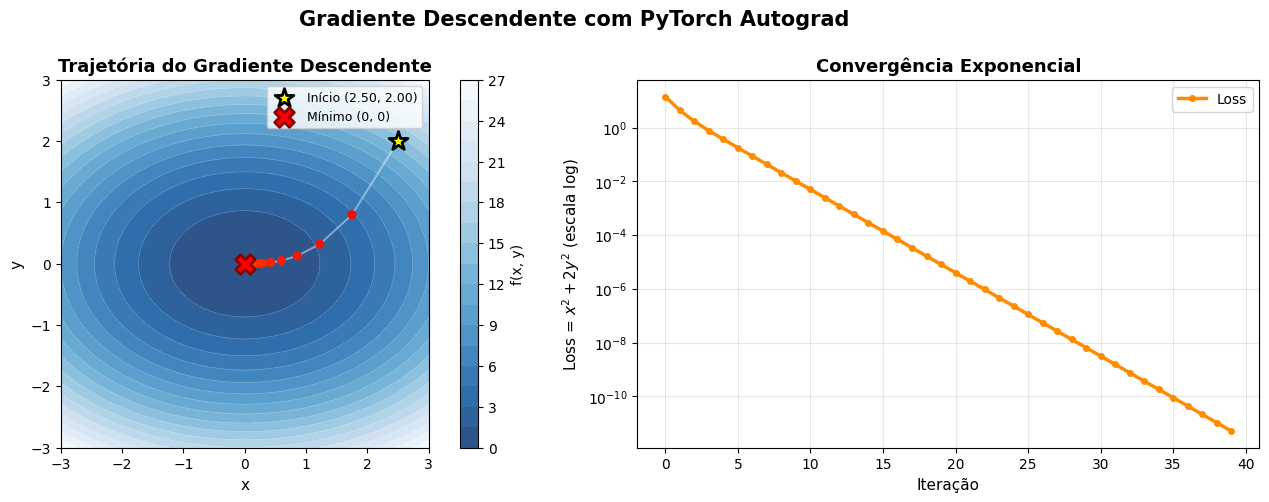

In [8]:
# Visualizar a trajetória e convergência
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='white')

# ─────────────────────────────────────────────────────────
# Painel 1: Mapa de contorno + trajetória do GD
# ─────────────────────────────────────────────────────────

# Criar grid para visualizar a função
xg = np.linspace(-3, 3, 200)
yg = np.linspace(-3, 3, 200)
XX, YY = np.meshgrid(xg, yg)
ZZ = XX**2 + 2*YY**2

# Desenhar curvas de nível (contornos)
contour = axes[0].contourf(XX, YY, ZZ, levels=25, cmap='Blues_r', alpha=0.85)
axes[0].contour(XX, YY, ZZ, levels=25, colors='white', linewidths=0.4, alpha=0.5)
cbar = plt.colorbar(contour, ax=axes[0], label='f(x, y)')

# Converter histórico para arrays
traj_x = np.array(history['x'])
traj_y = np.array(history['y'])

# Desenhar trajetória com gradiente de cor
for i in range(len(traj_x) - 1):
    alpha = 0.4 + 0.6 * (i / len(traj_x))
    axes[0].plot(traj_x[i:i+2], traj_y[i:i+2], 'w-', lw=1.5, alpha=alpha)

# Marcar pontos da trajetória
scatter = axes[0].scatter(traj_x, traj_y, c=range(len(traj_x)),
                         cmap='autumn', s=30, zorder=5)

# Marcar início e fim
axes[0].scatter(traj_x[0], traj_y[0], s=200, marker='*',
               color='yellow', zorder=6, edgecolors='black', linewidth=2,
               label=f'Início ({traj_x[0]:.2f}, {traj_y[0]:.2f})')

axes[0].scatter(0, 0, s=200, marker='X', color='red', zorder=6,
               edgecolors='darkred', linewidth=2,
               label='Mínimo (0, 0)')

axes[0].set_xlabel('x', fontsize=11)
axes[0].set_ylabel('y', fontsize=11)
axes[0].set_title('Trajetória do Gradiente Descendente', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9, loc='upper right')
axes[0].grid(False)
axes[0].set_aspect('equal')

# ─────────────────────────────────────────────────────────
# Painel 2: Convergência da Loss
# ─────────────────────────────────────────────────────────

iterations = range(len(history['loss']))
axes[1].semilogy(iterations, history['loss'], color='darkorange',
                lw=2.5, marker='o', markersize=4, label='Loss')
axes[1].set_xlabel('Iteração', fontsize=11)
axes[1].set_ylabel('Loss = $x^2 + 2y^2$ (escala log)', fontsize=11)
axes[1].set_title('Convergência Exponencial', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3, which='both')
axes[1].legend(fontsize=10)

plt.suptitle('Gradiente Descendente com PyTorch Autograd', fontsize=15,
             fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('gradient_descent_2d.png', dpi=100, facecolor='white', edgecolor='none', bbox_inches='tight')
plt.show()

## 📊 Interpretação dos Resultados

**Painel Esquerdo**: Trajetória do algoritmo no espaço 2D
- Linhas azuis = contornos da função
- Pontos coloridos = passos da otimização
- O algoritmo converge ao mínimo (0, 0) de forma não linear

**Painel Direito**: Convergência da Loss
- Escala logarítmica mostra queda linear = convergência exponencial
- Primeiras iterações: queda rápida
- Iterações finais: progresso mais lento perto do mínimo

# Parte 3: Armadilhas Comuns

## ⚠️ Três Erros que Todo Iniciante Comete

### 1️⃣ Esquecer de `requires_grad=True`

```python
# ❌ ERRADO
x = torch.tensor([2.5])
y = x**2
y.backward()  # ERRO! x.grad é None

# ✅ CORRETO
x = torch.tensor([2.5], requires_grad=True)
```

PyTorch **não rastreia automaticamente**. Você deve ser explícito!

In [ ]:
# Demonstração do Erro 1
print("=== ARMADILHA 1: requires_grad=True ===\n")

x_without = torch.tensor([2.5])
y_without = x_without**2

x_with = torch.tensor([2.5], requires_grad=True)
y_with = x_with**2

print(f"Sem requires_grad:")
print(f"  x.grad = {x_without.grad}  ← None!")
print(f"\nCom requires_grad:")
y_with.backward()
print(f"  x.grad = {x_with.grad}  ← Funcionou! ✓")
print()

### 2️⃣ Esquecer de Zerar Gradientes

**PyTorch acumula gradientes por padrão!**

```python
# ❌ ERRADO — gradientes se somam
x = torch.tensor([2.0], requires_grad=True)
for i in range(3):
    y = x**2
    y.backward()
    # x.grad cresce: 4.0, 8.0, 12.0 (errado!)

# ✅ CORRETO — zerar antes de each backward()
x = torch.tensor([2.0], requires_grad=True)
for i in range(3):
    x.grad.zero_()
    y = x**2
    y.backward()
    # x.grad permanece: 4.0, 4.0, 4.0 ✓
```

In [ ]:
# Demonstração do Erro 2
print("=== ARMADILHA 2: Acúmulo de Gradientes ===\n")

# Sem zerar gradientes
x_acum = torch.tensor([2.0], requires_grad=True)
grads_sem_zero = []

for i in range(3):
    y = x_acum**2
    y.backward()
    grads_sem_zero.append(x_acum.grad.item())
    # NÃO zerando — gradiente se acumula!

print(f"SEM zerar gradientes:")
print(f"  Iteração 0: grad = {grads_sem_zero[0]:.1f}")
print(f"  Iteração 1: grad = {grads_sem_zero[1]:.1f}  ← Dobrou!")
print(f"  Iteração 2: grad = {grads_sem_zero[2]:.1f}  ← Triplicou!")

# COM zerar gradientes
x_zero = torch.tensor([2.0], requires_grad=True)
grads_com_zero = []

for i in range(3):
    x_zero.grad.zero_()  # Limpar antes de cada backward
    y = x_zero**2
    y.backward()
    grads_com_zero.append(x_zero.grad.item())

print(f"\nCOM zerar gradientes (correto):")
print(f"  Iteração 0: grad = {grads_com_zero[0]:.1f}")
print(f"  Iteração 1: grad = {grads_com_zero[1]:.1f}  ✓")
print(f"  Iteração 2: grad = {grads_com_zero[2]:.1f}  ✓")
print()

### 3️⃣ Atualizar Parâmetros Dentro do Grafo

**Problema**: Se você atualizar parâmetros enquanto o grafo está **ativo**, o PyTorch tentará calcular a derivada da própria atualização — causando comportamento estranho!

```python
# ❌ ERRADO — atualização registrada no grafo
x = torch.tensor([2.0], requires_grad=True)
for i in range(3):
    y = x**2
    y.backward()
    x = x - 0.1 * x.grad  # ← Problema! Quebrando o link

# ✅ CORRETO — usar with torch.no_grad()
x = torch.tensor([2.0], requires_grad=True)
for i in range(3):
    y = x**2
    y.backward()
    with torch.no_grad():  # Sair do grafo
        x -= 0.1 * x.grad
```

In [ ]:
# Demonstração do Erro 3
print("=== ARMADILHA 3: Atualizar dentro do grafo ===\n")

# Tentativa ERRADA — atualizar sem torch.no_grad()
x_wrong = torch.tensor([2.0], requires_grad=True)
print(f"Antes: x.requires_grad = {x_wrong.requires_grad}")

y = x_wrong**2
y.backward()

# Atualizar ERRADO — sem proteção
x_wrong = x_wrong - 0.1 * x_wrong.grad
print(f"Depois (sem torch.no_grad()): x.requires_grad = {x_wrong.requires_grad}")
print(f"  ⚠️ Aviso: requires_grad still True, mas o grafo foi quebrado\n")

# Forma CORRETA — com torch.no_grad()
x_correct = torch.tensor([2.0], requires_grad=True)
y = x_correct**2
y.backward()

with torch.no_grad():
    x_correct -= 0.1 * x_correct.grad

print(f"Depois (com torch.no_grad()): x.requires_grad = {x_correct.requires_grad}")
print(f"  ✓ Valor atualizado sem afetar o grafo!")
print()

---

## ? Template Rápido para Otimização

```python
x = torch.tensor([...], requires_grad=True)
lr = 0.01  # learning rate

for epoch in range(n_epochs):
    x.grad.zero_()              # 1. Limpar gradientes antigos
    loss = f(x)                 # 2. Forward pass
    loss.backward()             # 3. Calcular gradientes
    
    with torch.no_grad():       # 4. Atualizar sem registrar no grafo
        x -= lr * x.grad
    
    if epoch % 10 == 0:
        print(f"Loss: {loss.item():.6f}")
```

**Ordem obrigatória**: `zero_() → forward → backward() → atualizar com torch.no_grad()`

# Parte 4: Exercícios Práticos

Agora é sua vez! Tente resolver estes exercícios usando autograd:

## Exercício 1: Minimizar $f(x) = (x-3)^2$

Encontre o mínimo de $f(x) = (x-3)^2$ começando de $x_0 = 0$.
- **Mínimo esperado**: $x = 3$ com $f(3) = 0$
- **Learning rate**: 0.1
- **Iterações**: 50

Dicas:
1. Defina `x = torch.tensor([0.0], requires_grad=True)`
2. Loop: forward → backward → atualizar (com `torch.no_grad()`)
3. Plote a trajetória de $x$ vs iterações

EXERCÍCIO 1: Minimizar f(x) = (x-3)²
Iter              x         Loss
--------------------------------
0          0.000000     9.000000
10         2.677877     0.103763
20         2.965412     0.001196
30         2.996286     0.000014
40         2.999601     0.000000
--------------------------------

✓ Solução encontrada:
  x final = 2.99995732  (esperado: 3.0)
  Loss final = 2.85e-09  (esperado: ~0)


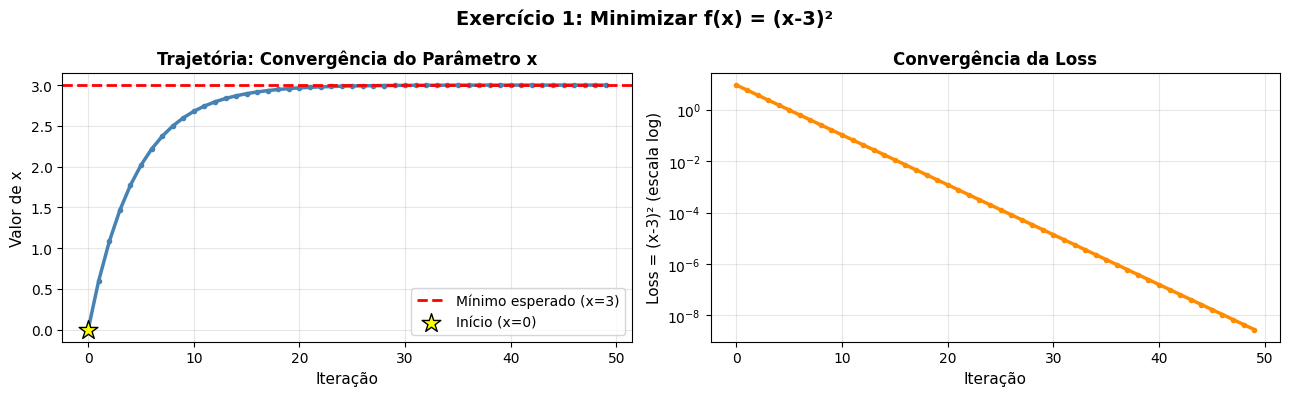

In [9]:
# Espaço para você resolver o Exercício 1
# SOLUÇÃO: Minimizar f(x) = (x-3)²

x = torch.tensor([0.0], requires_grad=True)
learning_rate = 0.1
n_iters = 50

history_x = []
history_loss = []

print("=" * 50)
print("EXERCÍCIO 1: Minimizar f(x) = (x-3)²")
print("=" * 50)
print(f"{'Iter':<6} {'x':>12} {'Loss':>12}")
print("-" * 32)

for i in range(n_iters):
    if x.grad is not None:
        x.grad.zero_()

    loss = (x - 3)**2
    history_x.append(x.item())
    history_loss.append(loss.item())

    loss.backward()

    if i % 10 == 0:
        print(f"{i:<6} {x.item():>12.6f} {loss.item():>12.6f}")

    with torch.no_grad():
        x -= learning_rate * x.grad

print("-" * 32)
print(f"\n✓ Solução encontrada:")
print(f"  x final = {x.item():.8f}  (esperado: 3.0)")
print(f"  Loss final = {history_loss[-1]:.2e}  (esperado: ~0)")

# Visualizar convergência
fig, axes = plt.subplots(1, 2, figsize=(13, 4), facecolor='white')

# Painel 1: Trajetória de x
axes[0].plot(history_x, color='steelblue', lw=2.5, marker='o', markersize=3)
axes[0].axhline(3.0, color='red', lw=2, ls='--', label='Mínimo esperado (x=3)')
axes[0].scatter([0], [0.0], s=200, color='yellow', marker='*',
               zorder=5, edgecolors='black', label='Início (x=0)')
axes[0].set_xlabel('Iteração', fontsize=11)
axes[0].set_ylabel('Valor de x', fontsize=11)
axes[0].set_title('Trajetória: Convergência do Parâmetro x', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Painel 2: Loss
axes[1].semilogy(history_loss, color='darkorange', lw=2.5, marker='o', markersize=3)
axes[1].set_xlabel('Iteração', fontsize=11)
axes[1].set_ylabel('Loss = (x-3)² (escala log)', fontsize=11)
axes[1].set_title('Convergência da Loss', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, which='both')

plt.suptitle('Exercício 1: Minimizar f(x) = (x-3)²', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('exercicio1.png', dpi=100, facecolor='white', edgecolor='none', bbox_inches='tight')
plt.show()

## Exercício 2: Fit de Parâmetros em uma Reta

**Objetivo**: Encontrar os parâmetros de uma reta que melhor se encaixa nos dados.

Os dados são gerados pela função: $y = 2x + 3 + \text{ruído}$

Você deve aprender:
- `w` (slope/inclinação)
- `b` (intercept)

Minimizando a **Mean Squared Error (MSE)**:
$$\text{MSE} = \frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2$$

onde $\hat{y}_i = w \cdot x_i + b$

**Passos:**
1. Gere dados: `x = torch.linspace(0, 10, 100)` e `y = 2*x + 3 + ruído`
2. Inicialize `w` e `b` com `requires_grad=True`
3. Loop de otimização com MSE
4. Plote: dados (pontos) vs reta encaixada (linha)

EXERCÍCIO 2: Fit de Reta (Linear Regression)
Iter              w            b     MSE Loss
---------------------------------------------
0          1.000000     0.000000    73.171379
50         2.255497     1.325784     0.990583
100        2.153983     2.000924     0.517202
150        2.092342     2.410877     0.342664
200        2.054913     2.659805     0.278311
250        2.032186     2.810957     0.254583
300        2.018386     2.902738     0.245835
350        2.010006     2.958467     0.242610
400        2.004918     2.992307     0.241420
450        2.001829     3.012855     0.240982
---------------------------------------------

✓ Parâmetros aprendidos:
  w (slope) = 1.999953    (esperado: 2.0)
  b (intercept) = 3.025331  (esperado: 3.0)
  MSE Loss final = 0.240822


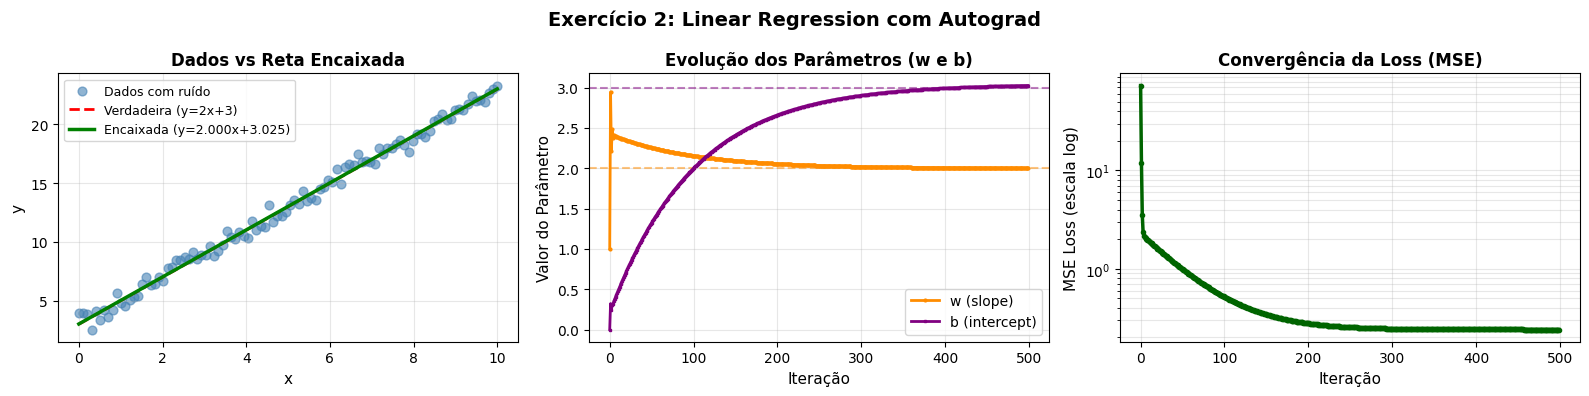

In [12]:
# Espaço para você resolver o Exercício 2
# SOLUÇÃO: Fit de parâmetros em uma reta

# Gerar dados (y = 2x + 3 + ruído)
torch.manual_seed(42)
x_data = torch.linspace(0, 10, 100)
y_true = 2*x_data + 3
noise = torch.randn_like(x_data) * 0.5
y_data = y_true + noise

# Inicializar parâmetros (comece com valores aleatórios)
w = torch.tensor([1.0], requires_grad=True)
b = torch.tensor([0.0], requires_grad=True)

learning_rate = 0.02
n_iters = 500

history_loss_ex2 = []
history_w = []
history_b = []

print("=" * 60)
print("EXERCÍCIO 2: Fit de Reta (Linear Regression)")
print("=" * 60)
print(f"{'Iter':<6} {'w':>12} {'b':>12} {'MSE Loss':>12}")
print("-" * 45)

for i in range(n_iters):
    # Limpar gradientes antigos
    if w.grad is not None:
        w.grad.zero_()
    if b.grad is not None:
        b.grad.zero_()

    # Forward pass: predição + MSE
    y_pred = w * x_data + b
    loss = torch.mean((y_data - y_pred)**2)  # MSE

    # Registrar histórico
    history_loss_ex2.append(loss.item())
    history_w.append(w.item())
    history_b.append(b.item())

    # Backward pass
    loss.backward()

    # Mostrar progresso
    if i % 50 == 0:
        print(f"{i:<6} {w.item():>12.6f} {b.item():>12.6f} {loss.item():>12.6f}")

    # Atualizar parâmetros
    with torch.no_grad():
        w -= learning_rate * w.grad
        b -= learning_rate * b.grad

print("-" * 45)
print(f"\n✓ Parâmetros aprendidos:")
print(f"  w (slope) = {w.item():.6f}    (esperado: 2.0)")
print(f"  b (intercept) = {b.item():.6f}  (esperado: 3.0)")
print(f"  MSE Loss final = {history_loss_ex2[-1]:.6f}")

# Visualizações
fig, axes = plt.subplots(1, 3, figsize=(16, 4), facecolor='white')

# Converter para lista (funciona sem numpy)
x_list = x_data.tolist()
y_list = y_data.tolist()
y_true_list = y_true.tolist()
y_fitted = [w.item() * xi + b.item() for xi in x_list]

# Painel 1: Dados + Reta encaixada
axes[0].scatter(x_list, y_list, alpha=0.6, s=40,
               color='steelblue', label='Dados com ruído')
axes[0].plot(x_list, y_true_list, 'r--', lw=2,
            label='Verdadeira (y=2x+3)')
axes[0].plot(x_list, y_fitted, 'g-', lw=2.5,
            label=f'Encaixada (y={w.item():.3f}x+{b.item():.3f})')
axes[0].set_xlabel('x', fontsize=11)
axes[0].set_ylabel('y', fontsize=11)
axes[0].set_title('Dados vs Reta Encaixada', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Painel 2: Convergência dos parâmetros
axes[1].plot(history_w, label='w (slope)', color='darkorange', lw=2, marker='o', markersize=2)
axes[1].axhline(2.0, color='darkorange', ls='--', alpha=0.5)
axes[1].plot(history_b, label='b (intercept)', color='purple', lw=2, marker='s', markersize=2)
axes[1].axhline(3.0, color='purple', ls='--', alpha=0.5)
axes[1].set_xlabel('Iteração', fontsize=11)
axes[1].set_ylabel('Valor do Parâmetro', fontsize=11)
axes[1].set_title('Evolução dos Parâmetros (w e b)', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# Painel 3: Loss
axes[2].semilogy(history_loss_ex2, color='darkgreen', lw=2.5, marker='o', markersize=3)
axes[2].set_xlabel('Iteração', fontsize=11)
axes[2].set_ylabel('MSE Loss (escala log)', fontsize=11)
axes[2].set_title('Convergência da Loss (MSE)', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3, which='both')

plt.suptitle('Exercício 2: Linear Regression com Autograd', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('exercicio2.png', dpi=100, facecolor='white', edgecolor='none', bbox_inches='tight')
plt.show()

---

EXERCÍCIO 2b: Fit de parábola (y = w1*x² + w2*x + b)
Iter             w1           w2            b     MSE Loss
----------------------------------------------------------
0          0.100000     0.100000     0.000000     0.785469
50         0.125131     0.583090    -0.062139     0.168027
100        0.157941     0.830933    -0.113606     0.028932
150        0.182814     0.922115    -0.150159     0.007189
200        0.200930     0.955661    -0.176592     0.002713
250        0.214068     0.968003    -0.195744     0.001302
300        0.223591     0.972544    -0.209626     0.000688
350        0.230493     0.974214    -0.219687     0.000383
400        0.235496     0.974829    -0.226979     0.000225
450        0.239122     0.975055    -0.232265     0.000142
----------------------------------------------------------

✓ Parâmetros aprendidos (espaço normalizado):
  w1 (coef. x²) = 0.241750
  w2 (coef. x)  = 0.975138
  b (intercept) = -0.236095
  MSE Loss final = 0.000099


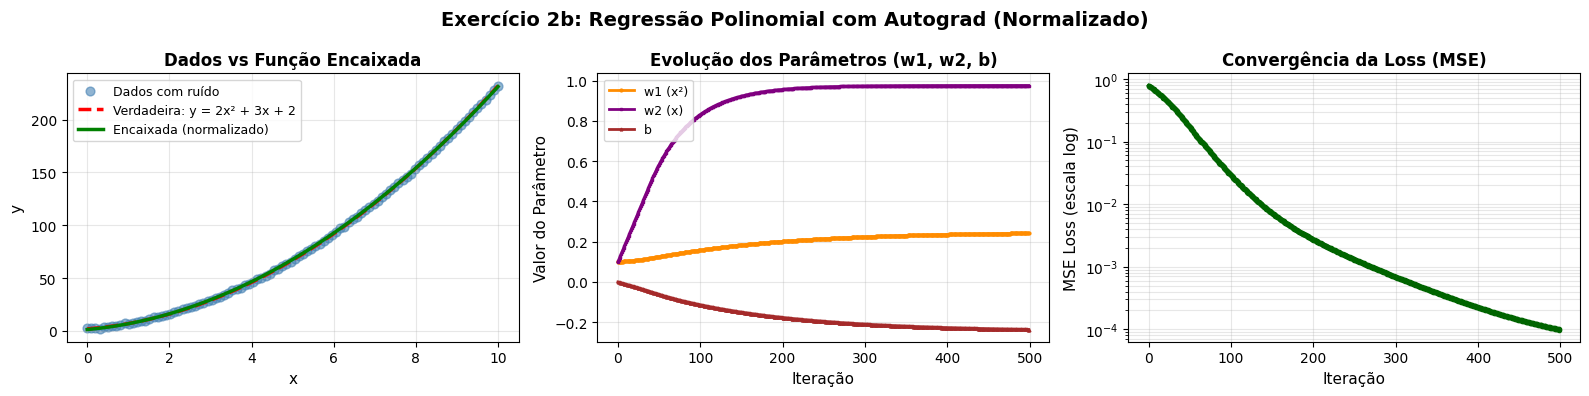

In [18]:
# Espaço para você resolver o Exercício 2b
# SOLUÇÃO: Fit de parâmetros em uma parábola

# Gerar dados (y = 2x^2 + 3x + 2 + ruído)
torch.manual_seed(42)
x_data = torch.linspace(0, 10, 100)

# ✅ NORMALIZAR os dados para evitar exploding gradients
x_mean = x_data.mean()
x_std = x_data.std()
x_normalized = (x_data - x_mean) / x_std  # Média 0, desvio padrão 1

y_true = 2*x_data**2 + 3*x_data + 2
noise = torch.randn_like(x_data) * 0.5
y_data = y_true + noise

# Normalizar y também
y_mean = y_data.mean()
y_std = y_data.std()
y_normalized = (y_data - y_mean) / y_std

# Inicializar parâmetros (comece com valores pequenos e aleatórios)
w1 = torch.tensor([0.1], dtype=torch.float32, requires_grad=True)
w2 = torch.tensor([0.1], dtype=torch.float32, requires_grad=True)
b = torch.tensor([0.0], dtype=torch.float32, requires_grad=True)

# ✅ Learning rate muito menor
learning_rate = 0.01
n_iters = 500

history_loss_ex2 = []
history_w1 = []
history_w2 = []
history_b = []

print("=" * 70)
print("EXERCÍCIO 2b: Fit de parábola (y = w1*x² + w2*x + b)")
print("=" * 70)
print(f"{'Iter':<6} {'w1':>12} {'w2':>12} {'b':>12} {'MSE Loss':>12}")
print("-" * 58)

for i in range(n_iters):
    # Limpar gradientes antigos
    if w1.grad is not None:
        w1.grad.zero_()
    if w2.grad is not None:
        w2.grad.zero_()
    if b.grad is not None:
        b.grad.zero_()

    # Forward pass: predição + MSE (usando dados normalizados)
    y_pred = w1 * x_normalized**2 + w2 * x_normalized + b
    loss = torch.mean((y_normalized - y_pred)**2)  # MSE

    # Registrar histórico
    history_loss_ex2.append(loss.item())
    history_w1.append(w1.item())
    history_w2.append(w2.item())
    history_b.append(b.item())

    # Backward pass
    loss.backward()

    # ✅ Clip de gradientes para evitar valores extremos
    torch.nn.utils.clip_grad_norm_([w1, w2, b], max_norm=1.0)

    # Mostrar progresso a cada 50 iterações
    if i % 50 == 0:
        print(f"{i:<6} {w1.item():>12.6f} {w2.item():>12.6f} {b.item():>12.6f} {loss.item():>12.6f}")

    # Atualizar parâmetros
    with torch.no_grad():
        w1 -= learning_rate * w1.grad
        w2 -= learning_rate * w2.grad
        b -= learning_rate * b.grad

print("-" * 58)
print(f"\n✓ Parâmetros aprendidos (espaço normalizado):")
print(f"  w1 (coef. x²) = {w1.item():.6f}")
print(f"  w2 (coef. x)  = {w2.item():.6f}")
print(f"  b (intercept) = {b.item():.6f}")
print(f"  MSE Loss final = {history_loss_ex2[-1]:.6f}")

# Visualizações
fig, axes = plt.subplots(1, 3, figsize=(16, 4), facecolor='white')

# Converter para lista (funciona sem numpy)
x_list = x_data.tolist()
x_norm_list = x_normalized.tolist()
y_list = y_data.tolist()
y_true_list = y_true.tolist()

# Predições no espaço normalizado
y_pred_norm = [w1.item() * xn**2 + w2.item() * xn + b.item()
               for xn in x_norm_list]

# Desnormalizar as predições de volta ao espaço original
y_fitted = [y_pred * y_std + y_mean for y_pred in y_pred_norm]

# Painel 1: Dados + Parábola encaixada
axes[0].scatter(x_list, y_list, alpha=0.6, s=40,
               color='steelblue', label='Dados com ruído')
axes[0].plot(x_list, y_true_list, 'r--', lw=2.5,
            label=f'Verdadeira: y = 2x² + 3x + 2')
axes[0].plot(x_list, y_fitted, 'g-', lw=2.5,
            label=f'Encaixada (normalizado)')
axes[0].set_xlabel('x', fontsize=11)
axes[0].set_ylabel('y', fontsize=11)
axes[0].set_title('Dados vs Função Encaixada', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Painel 2: Evolução dos parâmetros
axes[1].plot(history_w1, label='w1 (x²)', color='darkorange', lw=2, marker='o', markersize=2)
axes[1].plot(history_w2, label='w2 (x)', color='purple', lw=2, marker='s', markersize=2)
axes[1].plot(history_b, label='b', color='brown', lw=2, marker='^', markersize=2)
axes[1].set_xlabel('Iteração', fontsize=11)
axes[1].set_ylabel('Valor do Parâmetro', fontsize=11)
axes[1].set_title('Evolução dos Parâmetros (w1, w2, b)', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# Painel 3: Loss
axes[2].semilogy(history_loss_ex2, color='darkgreen', lw=2.5, marker='o', markersize=3)
axes[2].set_xlabel('Iteração', fontsize=11)
axes[2].set_ylabel('MSE Loss (escala log)', fontsize=11)
axes[2].set_title('Convergência da Loss (MSE)', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3, which='both')

plt.suptitle('Exercício 2b: Regressão Polinomial com Autograd (Normalizado)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('exercicio2b.png', dpi=100, facecolor='white', edgecolor='none', bbox_inches='tight')
plt.show()

---

# 📚 Resumo e Próximos Passos

## ✅ Conceitos Cobertos
- Diferenciação automática (Autograd)
- Grafo computacional (DAG)
- Backpropagation e regra da cadeia
- Gradiente descendente em 1D e 2D
- Armadilhas comuns

## 🚀 Próximos Tópicos
1. **Otimizadores**: `torch.optim.SGD()`, `torch.optim.Adam()`
2. **Redes Neurais**: `torch.nn.Linear()`, `torch.nn.Module`
3. **Loss Functions**: `F.mse_loss()`, `F.cross_entropy()`

## 🔗 Documentação
- **PyTorch Autograd**: https://pytorch.org/docs/stable/autograd.html
- **PyTorch Tutorials**: https://pytorch.org/tutorials/

## 💡 Dica Final
Autograd é um superpoder do PyTorch. Depois que você domina isso, treinar redes neurais fica muito mais simples!